### 크롤링
-웹 사이트 내에서 필요한 데이터(텍스트/ 링크/ 속성 등)를 수집하는 기술
-크롤링이 진행되는 방법은 사람이 하는 수집 프로세스를 세분화해서 작성한다
-사람이 할 수 있는 수준의 수집을 진행
-함수를 외우는 방식보다는, 절차의 이해와 대화를 하는 형태로 진행하는게 학습에 효율적

### 통신의 기초는 요청과 응답
- 클라이언트 = 요청하는 주체(request)
- 서버 = 응답하는 주체(response)
- 사람이 사이트를 요청하는 방법 : 브라우저 -> url을 통해 요청 -> 서버는 html 파일을 반환

### 동적 크롤링 / 정적 크롤링
- 정적 크롤링
       -  서버에 요청을 보냈을 때 이미 완성된 html 문서를 그대로 긁어오는 방식
       -  속도가 빠르고 서버 자원을 적게 소모함
  -동적 크롤링
    - 브라우저를 직접 띄우거나 제어해서, 자바스크립트까지 실행된 후의 최종 결과물을 수집하는 방식
    - 실제 브라우저를 실행하므로 메모리 점유율이 높고 속도가 정적 크롤링에 비해 느림
    - 사람이 웹서핑을 하는 것과 똑같이 행동할 수 있다. 수집범위가 넓다.
           

In [1]:
# 파이썬을 통해 사이트를 요청하는 라이브러리 확인해보기
! pip show requests

Name: requests
Version: 2.32.5
Summary: Python HTTP for Humans.
Home-page: https://requests.readthedocs.io
Author: Kenneth Reitz
Author-email: me@kennethreitz.org
License: Apache-2.0
Location: C:\Users\SMHRD\anaconda3\Lib\site-packages
Requires: certifi, charset_normalizer, idna, urllib3
Required-by: anaconda-auth, anaconda-catalogs, anaconda-client, anaconda-project, conda, conda-build, conda-libmamba-solver, conda-repo-cli, conda_package_streaming, cookiecutter, datashader, jupyterlab_server, panel, PyGithub, requests-file, requests-toolbelt, Sphinx, streamlit, tldextract


In [2]:
import requests as req

In [3]:
# 1. req를 통해서 사이트를 가져와보기.
result = req.get('https://www.naver.com')

print(dir(result)) # 객체에 적용할 수 있는 함수 목록
print(result) # 객체 상태 요약 정보
print(result.encoding) # 인코딩 정보

['__attrs__', '__bool__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__nonzero__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_content', '_content_consumed', '_next', 'apparent_encoding', 'close', 'connection', 'content', 'cookies', 'elapsed', 'encoding', 'headers', 'history', 'is_permanent_redirect', 'is_redirect', 'iter_content', 'iter_lines', 'json', 'links', 'next', 'ok', 'raise_for_status', 'raw', 'reason', 'request', 'status_code', 'text', 'url']
<Response [200]>
UTF-8


In [4]:
print(type(result)) # 객체 내부에 요소 반환 / 컴퓨터야 네가 가지고온거 어떤거야?
print(result.url) # 네가 요청한 주소는 여기야!
print(result.status_code) # 현재 상태를 코드로 알려줄게!

<class 'requests.models.Response'>
https://www.naver.com/
200


In [ ]:
# 2. response를 확인합시다(필수!)
# 응답 코드 종류
# 200번대 : 통신에 성공 -> 데이터 잘 받아왔어!
# 400번대 : 통신에 실패 -> 클라이언트 문제(사용자야 뭐가 잘못된 것 같은데 코드 수정해줘.)
# 500번대 : 통신에 실패 -> 서버에 문제 -> 서버님 제발 기능 고쳐주세요(우리가 코드 수정 할 수 없음.)

In [6]:
# 3. 내부 내용 확인해보기
# result.text : 응답 데이터 속에서 html 내용을 확인하는 기능
# 왜 text를 쓸까요? -> 컴퓨터에게 수많은 html 속에서 우리가 필요한 태그만 찾을 수 있도록 명령하기 위해서
# 현재 데이터 타입은 string 타입 -> 사람이 사용하는 언어 
# string 데이터를 컴퓨터가 이해할 수 있도록 html 문서로 변환해주는 것이 필요하다
result.text

'   <!doctype html> <html lang="ko" class="fzoom"> <head> <meta charset="utf-8"> <meta name="Referrer" content="origin"> <meta http-equiv="X-UA-Compatible" content="IE=edge"> <meta name="viewport" content="width=1190"> <title>NAVER</title> <meta name="apple-mobile-web-app-title" content="NAVER"/> <meta name="robots" content="index,nofollow"/> <meta name="description" content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요"/> <meta property="og:title" content="네이버"> <meta property="og:url" content="https://www.naver.com/"> <meta property="og:image" content="https://s.pstatic.net/static/www/mobile/edit/2016/0705/mobile_212852414260.png"> <meta property="og:description" content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요"/> <meta name="twitter:card" content="summary"> <meta name="twitter:title" content=""> <meta name="twitter:url" content="https://www.naver.com/"> <meta name="twitter:image" content="https://s.pstatic.net/static/www/mobile/edit/2016/0705/mobile_212852414260.png"> <meta name="twitter:description" 

'<!doctype html> <html lang="ko"><head> <meta charset="utf-8"> <meta name="referrer" content="strict-origin-when-cross-origin">  <meta name="format-detection" content="telephone=no,address=no,email=no"> <meta property="og:title" content="고양이 : 네이버 검색"/> <meta property="og:image" content="https://ssl.pstatic.net/sstatic/search/common/og_v3.png"> <meta property="og:description" content="\'고양이\'의 네이버 검색 결과입니다."> <meta name="description" lang="ko" content="\'고양이\'의 네이버 검색 결과입니다."> <title>고양이 : 네이버 검색</title> <link rel="shortcut icon" href="https://ssl.pstatic.net/sstatic/search/favicon/favicon_32x32_240820.ico">  <link rel="search" type="application/opensearchdescription+xml" href="https://ssl.pstatic.net/sstatic/search/opensearch-description.https.xml" title="Naver" /><link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/sstatic/search/pc/css/search1_260205.css?o=search"> <link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/sstatic/search/pc/css/search2_2602
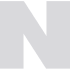
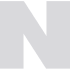

In [7]:
# 서버에 데이터를 전달하는 방법 : url에 직접 검색어를 포함하는 방식
# 장점 : 간단함 / 단점 : 검색어가 많아지거나 한글 처리가 복잡해질 때 관리가 어렵다
search_url = 'https://search.naver.com/search.naver?query=고양이'
result1 = req.get(search_url)
result1.text

In [8]:
# 실습) google 페이지에서  '동아일보'를 검색한 결과를 출력하세요
search_url = 'https://www.google.com/search'
result1 = req.get(search_url,
                 params = {'q' : '동아일보'})
print(result1)
print(result1.text)
# 구글에서는 컴퓨터가 사이트에 접근하는 것을 깐깐하게 걸러냄
# 접근은 하게 해주지만, 컴퓨터 프로그램인 것을 감지하고 차단용 스트립트를 보냈다.

<Response [200]>
<!DOCTYPE html><html lang="ko"><head><title>Google Search</title><style>body{background-color:#fff}</style><script nonce="eD9yUdawDyBH62ymL-E-ew">window.google = window.google || {};window.google.c = window.google.c || {cap:0};</script></head><body><noscript><style>table,div,span,p{display:none}</style><meta content="0;url=/httpservice/retry/enablejs?sei=04eNacqpCNSE0PEPv4zY0QY" http-equiv="refresh"><div style="display:block">&#47751; &#52488; &#50504;&#50640; &#51060;&#46041;&#54616;&#51648; &#50506;&#45716; &#44221;&#50864; <a href="/httpservice/retry/enablejs?sei=04eNacqpCNSE0PEPv4zY0QY">&#50668;&#44592;</a>&#47484; &#53364;&#47533;&#54616;&#49464;&#50836;.</div></noscript><script nonce="eD9yUdawDyBH62ymL-E-ew">(function(){var sctm=false;(function(){sctm&&google.tick("load","pbsst");}).call(this);})();</script><script nonce="eD9yUdawDyBH62ymL-E-ew">//# sourceMappingURL=data:application/json;charset=utf-8;base64,eyJ2ZXJzaW9uIjogMywic291cmNlcyI6WyIiXSwic291cmNlc0NvbnR

In [10]:
#1. 목적지 설정 : 구글의 검색 엔진 주소 입력
search_url = 'https://www.google.com/search'

#2. header 설정하기.
# 컴퓨터를 사람처럼 변장시키는 도구
header = {
    # 나는 파이썬 프로그램 아님 / 나 크롬 브라우저 쓰는 사람인
    "User-Agent" : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36",

    # 나 구글 메인페이지 검색 버튼 눌러서 들어옴
    "Refere" : "https://www.goole/com/" ,
    # 나 글자 그림 이미지 웹형식 다 잘 받을 수 있음
    'Accept' : 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7',
   # 나 한국어 쓰는 거 좋아함.
    'Accept-Language' : 'ko-KR,ko;q=0.9,en-US;q=0.8,en;q=0.7'
}

# 3. 요청 실행
result1 = req.get(search_url,
                 params = {'q' : '동아일보'},
                 headers = header)

print(result1)
print(result1.text)

<Response [200]>
<!DOCTYPE html><html lang="ko"><head><title>Google Search</title><style>body{background-color:var(--xhUGwc)}</style><script nonce="Wfc8eYvRTZujIFEqsusRrg">window.google = window.google || {};window.google.c = window.google.c || {cap:0};</script></head><body><noscript><style>table,div,span,p{display:none}</style><meta content="0;url=/httpservice/retry/enablejs?sei=x4-NaeXHLZW0qtsPwZLB6Qo" http-equiv="refresh"><div style="display:block">몇 초 안에 이동하지 않는 경우 <a href="/httpservice/retry/enablejs?sei=x4-NaeXHLZW0qtsPwZLB6Qo">여기</a>를 클릭하세요.</div></noscript><script nonce="Wfc8eYvRTZujIFEqsusRrg">(function(){var sctm=false;(function(){sctm&&google.tick("load","pbsst");}).call(this);})();</script><script nonce="Wfc8eYvRTZujIFEqsusRrg">//# sourceMappingURL=data:application/json;charset=utf-8;base64,eyJ2ZXJzaW9uIjogMywic291cmNlcyI6WyIiXSwic291cmNlc0NvbnRlbnQiOlsiICJdLCJuYW1lcyI6WyJjbG9zdXJlRHluYW1pY0J1dHRvbiJdLCJtYXBwaW5ncyI6IkFBQUE7QUFBQTtBQUFBO0FBQUE7QUFBQTtBQUFBO0FBQUEifQ==
(func

### string 데이터를 HTML로 변환하자

In [11]:
! pip show beautifulsoup4

Name: beautifulsoup4
Version: 4.13.5
Summary: Screen-scraping library
Home-page: https://www.crummy.com/software/BeautifulSoup/bs4/
Author: 
Author-email: Leonard Richardson <leonardr@segfault.org>
License: MIT License
Location: C:\Users\SMHRD\anaconda3\Lib\site-packages
Requires: soupsieve, typing-extensions
Required-by: conda-build, nbconvert


In [ ]:
# 라이브러리 불러오기
from bs4 import BeautifulSoup as bs
# 스톤숩 불러오지 않기

In [12]:
! pip show lxml 
! pip show html5lib

Name: lxml
Version: 5.3.0
Summary: Powerful and Pythonic XML processing library combining libxml2/libxslt with the ElementTree API.
Home-page: https://lxml.de/
Author: lxml dev team
Author-email: lxml-dev@lxml.de
License: BSD-3-Clause
Location: C:\Users\SMHRD\anaconda3\Lib\site-packages
Requires: 
Required-by: parsel, Scrapy
Name: html5lib
Version: 1.1
Summary: HTML parser based on the WHATWG HTML specification
Home-page: https://github.com/html5lib/html5lib-python
Author: 
Author-email: 
License: MIT License
Location: C:\Users\SMHRD\anaconda3\Lib\site-packages
Requires: six, webencodings
Required-by: 


In [13]:
! pip install html5lib